<h1> Section A

<b>1.) SCENARIO</b><br>
You are building a delivery fee calculator for a food delivery platform.<br> You have a NumPy
array of 50,000 order distances (in km) and need to compute a delivery fee for every
order simultaneously. <br>A teammate suggests iterating over the array using a Python
for-loop and appending results to a list.

In [3]:
import numpy as np
distances = np.array([2.5, 4.0, 1.2, 5.5])
fee_rate = 5
base_fee = 20
total_fees = base_fee + (distances * fee_rate) 
print("Vectorised Fees:", total_fees)

Vectorised Fees: [32.5 40.  26.  47.5]


<b> Explain why NumPy vectorisation is a technically superior approach to the for-loop
suggestion. In your answer, describe what broadcasting allows when a single scalar fee rate
(e.g., Rs 5 per km) is applied to the entire array, and identify one scenario where a Python loop
would still be necessary despite NumPy being available.

<b>Technical Superiority:</b> NumPy vectorisation allows operations on entire arrays at once using optimized, pre-compiled C code under the hood. This eliminates the overhead of Python's slow loop execution and dynamic type checking, making it significantly faster for large datasets like your 50,000 order distances.

<b>Broadcasting:</b> Broadcasting allows NumPy to take a single scalar value (like the Rs 5 per km fee rate) and virtually replicate it to match the shape of the 50,000-element distance array, applying the multiplication element-wise without creating multiple copies of the scalar in memory.

<b>When a Loop is Necessary: </b> A standard Python loop is still needed when operations are strictly sequential and depend on the result of a previous iteration (like calculating a cumulative running total with complex conditions), or when dealing with complex, heterogeneous data types that NumPy's structured C-arrays cannot handle.

<b>2.)SCENARIO</b><br>
You are working on a reporting pipeline for a food delivery platform. You have a Pandas
DataFrame with columns: order_id, restaurant_name, city, order_value,
delivery_time_mins, and rating. A colleague proposes filtering the DataFrame in a
for-loop once per restaurant and computing averages manually inside the loop

In [9]:
import pandas as pd
data = {
    'order_id': [101, 102, 103, 104, 105, 106, 107, 108],
    'restaurant_name': ['Spice Point', 'Burger Hub', 'Spice Point', 'Burger Hub', 'Pizza Corner', 'Spice Point', 'Pizza Corner', 'Burger Hub'],
    'city': ['Ahmedabad', 'Delhi', 'Ahmedabad', 'Delhi', 'Mumbai', 'Ahmedabad', 'Mumbai', 'Delhi'],
    'order_value': [250, 400, 300, 450, 600, 200, 550, 350],
    'delivery_time_mins': [30, 45, 25, 50, 40, 35, 38, 42],
    'rating': [4.5, 3.8, 4.2, 4.0, 4.8, 4.0, 4.5, 3.9]
}

df = pd.DataFrame(data)

result = df.groupby('restaurant_name').agg(
    avg_order_value=('order_value', 'mean'),
    avg_delivery_time=('delivery_time_mins', 'mean'),
    avg_rating=('rating', 'mean')
)

print(result)

                 avg_order_value  avg_delivery_time  avg_rating
restaurant_name                                                
Burger Hub                 400.0          45.666667    3.900000
Pizza Corner               575.0          39.000000    4.650000
Spice Point                250.0          30.000000    4.233333


<b>Explain why groupby() combined with agg() is the correct approach instead of the
for-loop strategy. Describe the specific method chain you would write to compute average order
value, average delivery time, and average rating per restaurant in a single operation, and
explain what the resulting DataFrame's index represents after the operation

<b>Why groupby() is Correct:</b> groupby() combined with agg() uses optimized internal hash maps to split the data, apply the aggregation, and combine the results. A for-loop requires manual subsetting of the DataFrame for each restaurant, which is computationally slow and leads to messy code. <br>
<b>Method Chain: </b>To get the averages for order_value, delivery_time_mins, and rating in a single operation, you would write: df.groupby('restaurant_name').agg({'order_value': 'mean', 'delivery_time_mins': 'mean', 'rating': 'mean'}). <br>
<b>Resulting Index: </b>After this operation, the resulting DataFrame's index represents the unique values of the grouped column, which in this case are the unique restaurant names.  

<b>3.)SCENARIO</b><br>
You are developing a monthly performance report for a food delivery startup. The report
must present three pieces of information side by side: (a) total orders placed per month
over a year, (b) the proportion of orders by cuisine type (Fast Food, Indian, Chinese,
Desserts), and (c) the distribution of delivery times across all orders.

<b>Identify the most appropriate Matplotlib chart type for each of the three metrics and
justify each choice based on the nature of the data. Then explain how plt.subplots() would be
configured to arrange all three charts in a single figure, and state whether a shared x-axis would
or would not be appropriate for this layout — and why.

<b>Line Chart:</b> The most appropriate choice for (a) Total orders per month, as it effectively shows continuity and trends over a 12-month time period.  Pie Chart or <br>
<b>Bar Chart:</b>  Best for (b) Proportion of orders by cuisine, as it directly represents parts of a whole for a distinct set of categories.<br>
<b>Histogram:</b>  The perfect choice for (c) Distribution of delivery times, as it is specifically designed to visualize the frequency spread and shape of continuous numerical data.<br> <b> Configuration: </b> You would use plt.subplots(1, 3) (1 row, 3 columns) to arrange all three charts neatly side-by-side in a single figure. <br> <b>Shared X-Axis:</b> A shared x-axis (sharex=True) would not be appropriate here. The three charts have completely distinct x-axes <br>representing different data types: months (time), cuisine types (categories), and delivery times (minutes). 

<b>4.)SCENARIO</b><br>
You are optimising a Matplotlib line chart that shows daily order volume for a food
delivery app over a 90-day period. The chart renders correctly but stakeholders keep
asking 'which day had the spike?' during every review meeting. The spike is the single
highest-value day in the array.

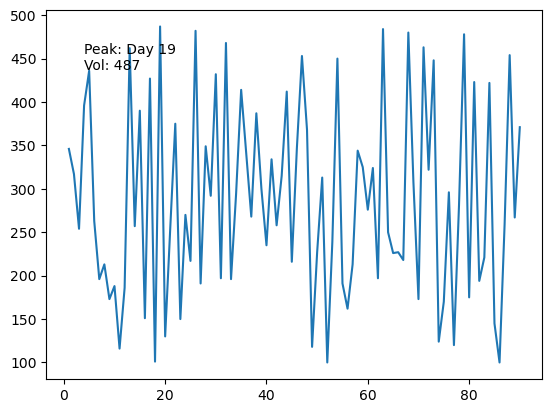

In [16]:
import matplotlib.pyplot as plt
import numpy as np

days = np.arange(1, 91)
orders = np.random.randint(100, 500, size=90)
max_day_index = np.argmax(orders)
max_day = days[max_day_index]
max_volume = orders[max_day_index]

plt.plot(days, orders)
plt.annotate(f'Peak: Day {max_day}\nVol: {max_volume}',
             xy=(max_day, max_volume), 
             xytext=(max_day-15, max_volume-50))
plt.show()

<b>Describe how you would use plt.annotate() to programmatically identify and mark
the maximum order day with an arrow pointing to the peak and a text label showing the day
number and volume. Name at least two specific parameters you would pass to plt.annotate()
and explain what each one controls in the rendered chart.

<b>Programmatic Identification: </b>You would first find the index of the maximum order volume using a function like np.argmax(), extract the specific day and volume, and then pass those exact coordinates to plt.annotate() to automatically mark the peak.<br><b>  Parameter 1 - xy:</b> This parameter takes a tuple (x, y) representing the exact data coordinates of the spike where the arrow will point. <br><b> Parameter 2 - xytext: </b>This parameter dictates the coordinates where the actual text label (showing day and volume) will be placed, allowing you to position it cleanly away from the line. 

<b>5.)SCENARIO</b><br>
You are designing a visual analysis of customer ratings for a food delivery app. Your
dataset has 10,000 rows. Each row belongs to one of three restaurant categories (Fast
Food, Fine Dining, Casual) and has a customer rating on a discrete 1–5 scale. Your
manager wants to understand how ratings are distributed within each category and
whether any category produces more extreme outliers.

<b>Compare sns.boxplot() and sns.violinplot() for this specific task. Which would you
recommend and why? Provide at least two data-specific reasons that reference properties of
this dataset (10,000 rows, 3 categories, discrete 1–5 scale), and explain one situation where the
other chart type would be preferable.

<b>Recommendation: </b>sns.boxplot() is the better choice here because your manager explicitly wants to identify "extreme outliers". Boxplots specifically map outliers as individual points beyond the whiskers, making them immediately visible. <br> <b> Data-Specific Reason 1 (Discrete Scale): </b>Because the ratings are on a discrete 1-5 scale, a Violinplot's continuous density estimation (KDE) might attempt to smooth out the data, creating artificial, misleading curves between the integer values. <br> <b> Data-Specific Reason 2 (10,000 Rows): </b>With a large dataset of 10,000 rows across 3 categories, a Boxplot provides a clean, exact statistical summary (median, quartiles) without the visual clutter of density curves.  When to use <br><b> Violinplot: </b> A Violinplot would be preferable if the ratings were a continuous variable (e.g., 4.25, 3.80) and you needed to see the exact shape, density, or multimodality of the distribution.

<b>6.)SCENARIO</b><br>
You are building a feature analysis report for a food delivery platform's data science
team before a regression model is trained. Your DataFrame contains eight numeric
columns: order_value, distance_km, delivery_time_mins, rating, discount_applied,
peak_hour_flag, restaurant_age_years, and driver_experience_years.

<b>Explain how you would generate and interpret a Seaborn correlation heatmap to
identify multicollinearity risks among these features. In your answer, describe what the colour
scale in the heatmap represents, how to read a specific cell value, and what correlation
magnitude threshold you would use to flag a potential multicollinearity problem — and why that
threshold is conventionally chosen.

<b>Generation & Interpretation: </b>You generate it by calling .corr() on your numeric columns to get the correlation matrix, and then passing that to sns.heatmap(). This helps visually identify multicollinearity (highly correlated independent variables) before training a regression model.  Colour 
<br><b>Scale:</b> A diverging colour scale represents both the direction and strength of the correlation. For example, dark shades at opposite ends indicate strong positive or negative correlations, while neutral/light shades in the middle represent zero or weak correlation. <br><b> Reading a Cell:</b> A specific cell (e.g., the intersection of distance_km and delivery_time_mins) displays a numerical value between -1.0 and 1.0, representing the exact Pearson correlation coefficient between those two features.<br><b>  Threshold:</b> A conventional threshold of 0.7 or 0.8 (absolute value) is commonly chosen. If two features cross this threshold, it implies they contain heavily redundant information, which can destabilize the regression model and make feature coefficients difficult to interpret.

<h1>Section B 

<h1>Task 1:</h1><br>
<b>Delivery Fee Array Calculator (NumPy)

In [27]:
import numpy as np
np.random.seed(42)
distances = np.random.uniform(low=1.0, high=15.0, size=25)

fees = 20 + (5 * distances)
mask = fees > 60
distances = distances[mask]
values = fees[mask]

for d, f in zip(distances, values):
    print(f"Distance: {d:.2f} km  |  Fee: Rs {f:.2f}")

print(f"Minimum Fee: Rs {np.min(fees):.2f}")
print(f"Maximum Fee: Rs {np.max(fees):.2f}")
print(f"Mean Fee: Rs {np.mean(fees):.2f}")
print(f"Standard Deviation: Rs {np.std(fees):.2f}")

Distance: 14.31 km  |  Fee: Rs 91.55
Distance: 11.25 km  |  Fee: Rs 76.24
Distance: 9.38 km  |  Fee: Rs 66.91
Distance: 13.13 km  |  Fee: Rs 85.63
Distance: 9.42 km  |  Fee: Rs 67.08
Distance: 10.91 km  |  Fee: Rs 74.57
Distance: 14.58 km  |  Fee: Rs 92.89
Distance: 12.65 km  |  Fee: Rs 83.27
Distance: 8.35 km  |  Fee: Rs 61.73
Distance: 9.57 km  |  Fee: Rs 67.83
Minimum Fee: Rs 26.44
Maximum Fee: Rs 92.89
Mean Fee: Rs 55.86
Standard Deviation: Rs 19.56


<h1>Task 2:</h1><br>
<b>Restaurant Performance Analyser (Pandas)

In [29]:
np.random.seed(99)

my_data = {
    'restaurant_name': np.random.choice(['Taco Bell', 'KFC', 'Burger King', 'Dominos', 'Subway'], 45),
    'city': np.random.choice(['Ahmedabad', 'Mumbai', 'Pune'], 45),
    'cuisine_type': np.random.choice(['Mexican', 'Fast Food', 'Italian'], 45),
    'order_value': np.random.uniform(150.0, 850.0, 45),
    'delivery_time_mins': np.random.uniform(15.0, 50.0, 45),
    'rating': np.random.uniform(2.5, 5.0, 45)
}

df_orders = pd.DataFrame(my_data)

final_summary = (
    df_orders.groupby('restaurant_name')
    .agg(
        mean_order_value=('order_value', 'mean'),
        mean_delivery_time=('delivery_time_mins', 'mean'),
        mean_rating=('rating', 'mean')
    )
    .loc[lambda row: (row['mean_rating'] > 4.0) & (row['mean_delivery_time'] < 35.0)]
    .sort_values(by='mean_order_value', ascending=False)
    .reset_index()
)

print(final_summary)

  restaurant_name  mean_order_value  mean_delivery_time  mean_rating
0     Burger King        510.960375           27.571674     4.073643


<h1>Task 3:</h1><br>
<b>Monthly Order Trend Dashboard (Matplotlib)

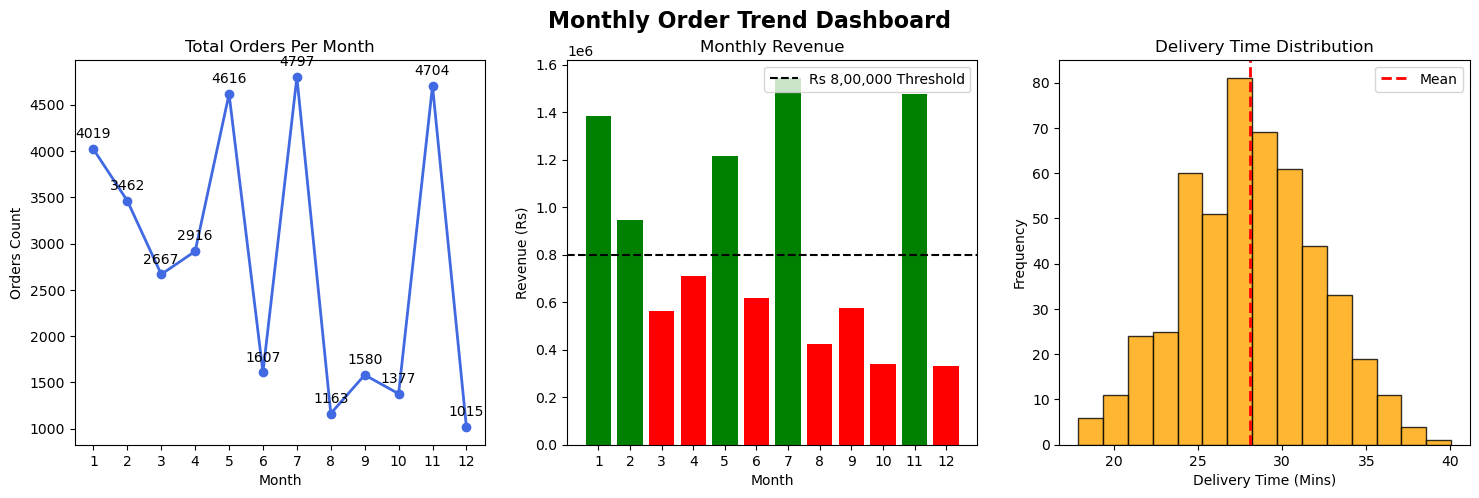

In [31]:
np.random.seed(45)
months = np.arange(1, 13)
total_orders = np.random.randint(1000, 5000, size=12)
avg_order_value = np.random.uniform(200.0, 400.0, size=12)
monthly_revenue = total_orders * avg_order_value

simulated_del_times = np.random.normal(loc=28.0, scale=4.0, size=500)  

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Monthly Order Trend Dashboard", fontsize=16, fontweight='bold') 
axes[0].plot(months, total_orders, marker='o', color='royalblue', linewidth=2)

for i in range(len(months)):
    axes[0].annotate(str(total_orders[i]), 
                     xy=(months[i], total_orders[i]), 
                     xytext=(0, 8), textcoords='offset points', ha='center')
axes[0].set_title("Total Orders Per Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Orders Count")
axes[0].set_xticks(months)
bar_colors = ['green' if rev > 800000 else 'red' for rev in monthly_revenue]
axes[1].bar(months, monthly_revenue, color=bar_colors)
axes[1].axhline(y=800000, color='black', linestyle='--', linewidth=1.5, label='Rs 8,00,000 Threshold')
axes[1].set_title("Monthly Revenue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue (Rs)")
axes[1].set_xticks(months)
axes[1].legend()
axes[2].hist(simulated_del_times, bins=15, color='orange', edgecolor='black', alpha=0.8)

sample_mean = np.mean(simulated_del_times)
axes[2].axvline(sample_mean, color='red', linestyle='--', linewidth=2, label='Mean')
axes[2].set_title("Delivery Time Distribution")
axes[2].set_xlabel("Delivery Time (Mins)")
axes[2].set_ylabel("Frequency")
axes[2].legend()
plt.show()
plt.show()

<h1>Task 4:</h1><br>
<b>Full EDA Pipeline — Food Delivery Insights (NumPy)

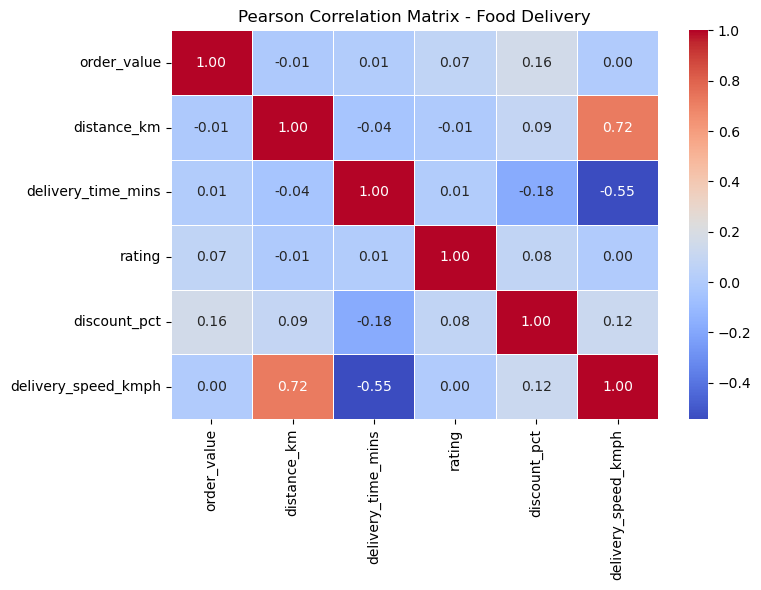

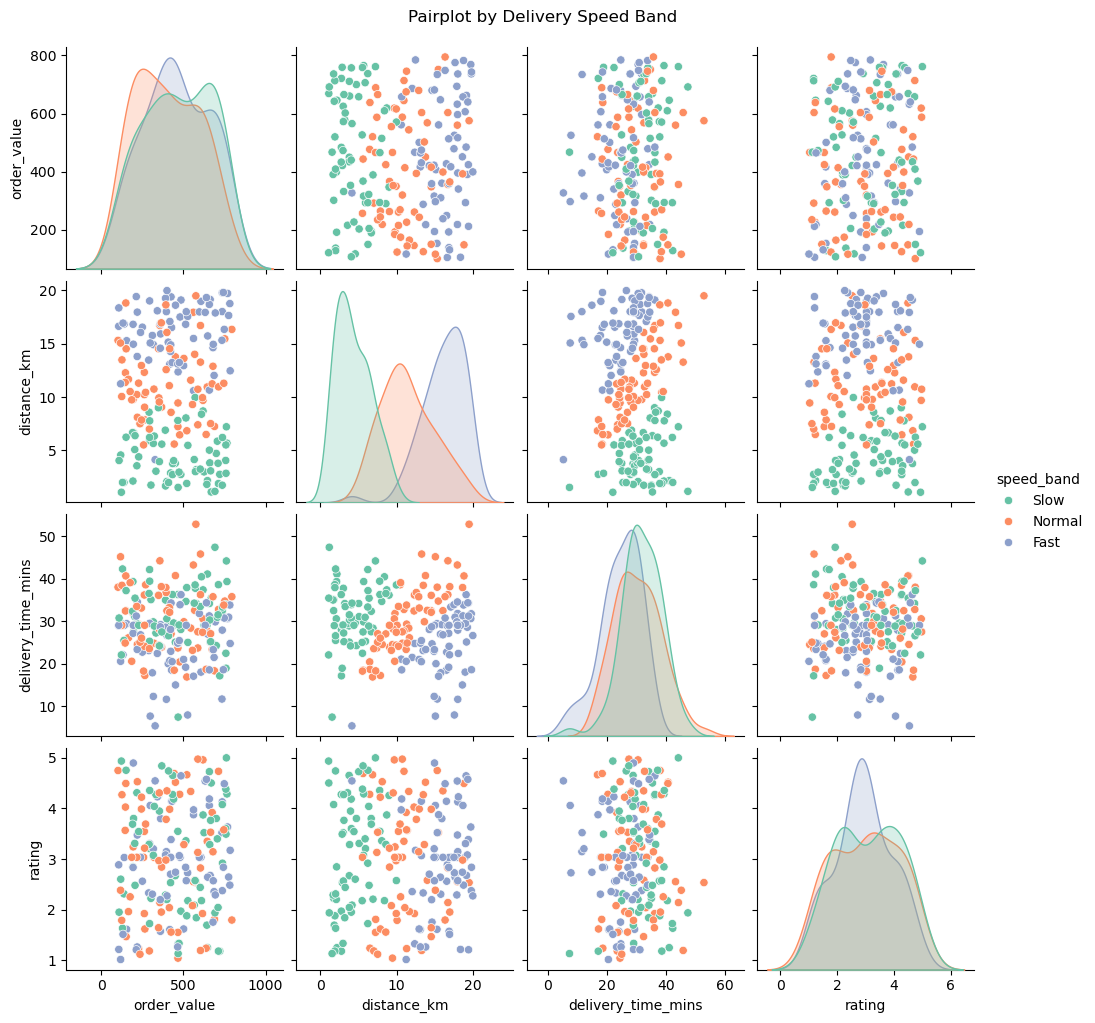

In [33]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(7) 
num_rows = 200

data_dict = {
    'order_value': np.random.uniform(100.0, 800.0, num_rows),
    'distance_km': np.random.uniform(1.0, 20.0, num_rows),
    'delivery_time_mins': np.random.normal(loc=30.0, scale=8.0, size=num_rows),
    'rating': np.random.uniform(1.0, 5.0, num_rows),
    'discount_pct': np.random.uniform(0.0, 30.0, num_rows)
}
eda_df = pd.DataFrame(data_dict)

five_percent = int(0.05 * num_rows)

null_idx_time = np.random.choice(num_rows, size=five_percent, replace=False)
null_idx_rating = np.random.choice(num_rows, size=five_percent, replace=False)

eda_df.loc[null_idx_time, 'delivery_time_mins'] = np.nan
eda_df.loc[null_idx_rating, 'rating'] = np.nan

eda_df['delivery_time_mins'].fillna(eda_df['delivery_time_mins'].median(), inplace=True)
eda_df['rating'].fillna(eda_df['rating'].median(), inplace=True)

eda_df['delivery_speed_kmph'] = eda_df['distance_km'] / (eda_df['delivery_time_mins'] / 60)

eda_df['speed_band'] = pd.qcut(eda_df['delivery_speed_kmph'], q=3, labels=['Slow', 'Normal', 'Fast'])

plt.figure(figsize=(8, 6))

numeric_df = eda_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix - Food Delivery")
plt.tight_layout()
plt.show()

pair_cols = ['order_value', 'distance_km', 'delivery_time_mins', 'rating', 'speed_band']
pair_plot = sns.pairplot(eda_df[pair_cols], hue='speed_band', palette='Set2')
pair_plot.fig.suptitle('Pairplot by Delivery Speed Band', y=1.02)

plt.show()